In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

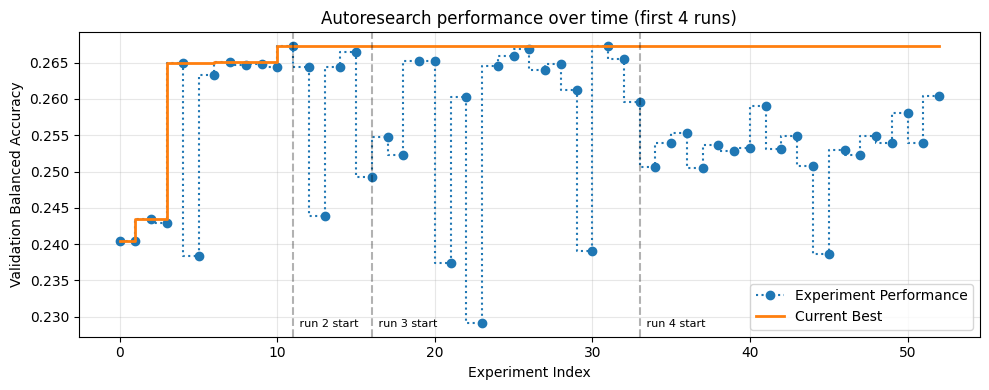

In [22]:
# Read results files (1..4) and combine val_acc in chronological order
files = [Path('../results') / f'{i}_run_results.tsv' for i in range(1,5)]
vals = []
for f in files:
    df = pd.read_csv(f, sep='	')
    vals.extend(df['val_acc'].tolist())

x = np.arange(len(vals))
vals = np.array(vals)
cumbest = np.maximum.accumulate(vals)

plt.figure(figsize=(10,4))
# dotted step for experiment performance (steps at left endpoint)
plt.step(x, vals, where='pre', linestyle=':', marker='o', color='C0', label='Experiment Performance')
# solid step for cumulative best
plt.step(x, cumbest, where='pre', linestyle='-', linewidth=2.0, color='C1', label='Current Best')

plt.xlabel('Experiment Index')
plt.ylabel('Validation Balanced Accuracy')
plt.title('Autoresearch performance over time (first 4 runs)')
plt.grid(alpha=0.3)
plt.legend()

# mark vertical separators between runs
run_counts = [len(pd.read_csv(Path('../results') / f'{i}_run_results.tsv', sep='	')) for i in range(1,5)]
sep = 0
for i, c in enumerate(run_counts[:-1], start=1):
    sep += c
    plt.axvline(sep, color='black', linestyle='--', alpha=0.3)
    plt.text(sep+0.2, plt.ylim()[0]+0.001, f' run {i+1} start', va='bottom', ha='left', fontsize=8, color='black')

plt.tight_layout()
plt.show()